<!--
  Licensed to the Apache Software Foundation (ASF) under one or more
  contributor license agreements.  See the NOTICE file distributed with
  this work for additional information regarding copyright ownership.
  The ASF licenses this file to You under the Apache License, Version 2.0
  (the "License"); you may not use this file except in compliance with
  the License.  You may obtain a copy of the License at

       http://www.apache.org/licenses/LICENSE-2.0

  Unless required by applicable law or agreed to in writing, software
  distributed under the License is distributed on an "AS IS" BASIS,
  WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
  See the License for the specific language governing permissions and
  limitations under the License.
-->

# Hudi BLOB Reader Demo — `read_blob()` round-trip

Walks through the **OUT_OF_LINE BLOB** and **INLINE BLOB** storage paths
end-to-end on the Oxford-IIIT Pet dataset. Same logic as
[`hudi_blob_reader_demo.py`](../hudi_blob_reader_demo.py), but as cells
you can edit + re-run — the toggles in cell 1 control feature variants
instead of shell env vars.

**What this demonstrates:**

| Feature | Toggle | What changes |
|---|---|---|
| Base file format | `BASE_FILE_FORMAT = "lance" | "parquet"` | Hudi base files |
| Blob storage | `BLOB_MODE = "out_of_line" | "inline"` | bytes in container vs in Hudi table |
| Inline read mode | `INLINE_READ_MODE = "content" | "descriptor"` | eager vs lazy byte reads (only meaningful when `BLOB_MODE == "inline"`) |

**Suggested walk-through:** Run All with the defaults
(`out_of_line`), watch the footprint comparison print at the end, then
flip `BLOB_MODE = "inline"` and Run All again to see the contrast.

## 1. Toggles

In [1]:
# ===== EDIT THESE =====
BASE_FILE_FORMAT  = "lance"      # "parquet" or "lance"
BLOB_MODE         = "inline"  # "out_of_line" or "inline"
INLINE_READ_MODE  = "descriptor"      # "content" or "descriptor" (only when BLOB_MODE == "inline")
N_SAMPLES         = 250

assert BASE_FILE_FORMAT in {"parquet", "lance"}
assert BLOB_MODE in {"out_of_line", "inline"}
assert INLINE_READ_MODE in {"content", "descriptor"}

## 2. Pre-flight cleanup

In [ ]:
import shutil
from pathlib import Path

for pattern in [
    "/tmp/hudi_*_pets",
    "/tmp/pets_blob_container.bin",
    "/tmp/staging_pets_*.parquet",
]:
    for p in Path("/").glob(pattern.lstrip("/")):
        if p.is_dir():
            shutil.rmtree(p, ignore_errors=True)
        elif p.is_file():
            p.unlink(missing_ok=True)

shutil.rmtree("spark-warehouse", ignore_errors=True)
print("✓ Wiped /tmp/hudi_*_pets, /tmp/pets_blob_container.bin, staging Parquet, spark-warehouse")

## 3. Pre-JVM env (driver heap)

In [3]:
# Pre-JVM env: must run BEFORE any `pyspark` import so the driver heap is
# set at JVM launch time. PySpark in local mode can't grow the heap later
# via SparkSession.config().
import os

DRIVER_MEMORY = "4g"   # bump to "8g" or "12g" for N >= 2000

os.environ.setdefault(
    "PYSPARK_SUBMIT_ARGS",
    f"--driver-memory {DRIVER_MEMORY} --conf spark.driver.maxResultSize=2g pyspark-shell",
)

'--driver-memory 4g --conf spark.driver.maxResultSize=2g pyspark-shell'

## 4. Imports

In [4]:
import io
from pathlib import Path

import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
from PIL import Image
from torchvision.datasets import OxfordIIITPet

from pyspark.sql import SparkSession
from IPython.display import Image as IPyImage, display

## 5. Configuration (derived from toggles)

In [5]:
CONFIG = {
    "dataset": "OxfordIIITPet",
    "table_path": f"/tmp/hudi_blob_reader_{BLOB_MODE}_{BASE_FILE_FORMAT}_pets",
    "table_name": f"pets_blob_reader_{BLOB_MODE}_{BASE_FILE_FORMAT}",
    "base_file_format": BASE_FILE_FORMAT,
    "blob_mode": BLOB_MODE,
    "inline_read_mode": INLINE_READ_MODE,
    "n_samples": N_SAMPLES,
    "blob_container_path": "/tmp/pets_blob_container.bin",
    "output_dir": "./outputs",
    "resolved_images_to_save": 3,
}

for k, v in CONFIG.items():
    print(f"  {k:22s}: {v}")

  dataset               : OxfordIIITPet
  table_path            : /tmp/hudi_blob_reader_inline_lance_pets
  table_name            : pets_blob_reader_inline_lance
  base_file_format      : lance
  blob_mode             : inline
  inline_read_mode      : descriptor
  n_samples             : 250
  blob_container_path   : /tmp/pets_blob_container.bin
  output_dir            : ./outputs
  resolved_images_to_save: 3


## 6. Resolve Hudi (and optionally Lance) jars

In [6]:
import sys
from pathlib import Path

def default_hudi_bundle_jar() -> str:
    # Defaults to the Apache 1.2.0-rc1 staging jar in ~/Downloads/. Grab it with:
    #   curl -L -o ~/Downloads/hudi-spark3.5-bundle_2.12-1.2.0-rc1.jar \
    #     https://repository.apache.org/content/repositories/orgapachehudi-1176/org/apache/hudi/hudi-spark3.5-bundle_2.12/1.2.0-rc1/hudi-spark3.5-bundle_2.12-1.2.0-rc1.jar
    # Override via HUDI_BUNDLE_JAR env var to point at a locally built bundle.
    return str(Path.home() / "Downloads" / "hudi-spark3.5-bundle_2.12-1.2.0-rc1.jar")

def default_lance_bundle_jar() -> str:
    # Defaults to the Maven Central Lance 0.4.0 jar in ~/Downloads/. Grab it with:
    #   curl -L -o ~/Downloads/lance-spark-bundle-3.5_2.12-0.4.0.jar \
    #     https://repo1.maven.org/maven2/com/lancedb/lance-spark-bundle-3.5_2.12/0.4.0/lance-spark-bundle-3.5_2.12-0.4.0.jar
    return str(Path.home() / "Downloads" / "lance-spark-bundle-3.5_2.12-0.4.0.jar")

def resolve_jars(base_file_format: str) -> str:
    hudi_jar = os.getenv("HUDI_BUNDLE_JAR", default_hudi_bundle_jar())
    if not Path(hudi_jar).is_file():
        sys.exit(
            f"ERROR: HUDI_BUNDLE_JAR does not exist at {hudi_jar}\n"
            "Download the Apache 1.2.0-rc1 staging jar to ~/Downloads/ "
            "or set HUDI_BUNDLE_JAR=/abs/path/to/locally-built.jar "
            "before launching jupyter."
        )
    if base_file_format != "lance":
        return hudi_jar
    lance_jar = os.getenv("LANCE_BUNDLE_JAR", default_lance_bundle_jar())
    if not Path(lance_jar).is_file():
        sys.exit(
            f"ERROR: LANCE_BUNDLE_JAR does not exist at {lance_jar}\n"
            "Download lance-spark-bundle-3.5_2.12-0.4.0.jar from Maven Central "
            "to ~/Downloads/ or set LANCE_BUNDLE_JAR=/abs/path/to/jar "
            "before launching jupyter."
        )
    return f"{hudi_jar},{lance_jar}"

## 7. Spark session

In [7]:
# Note: `hoodie.read.blob.inline.mode` is intentionally NOT set on the
# SparkSession. If it were, every Hudi load — including the one
# `read_blob()` runs internally — would suppress INLINE bytes. Instead
# the descriptor inspection step in cell 12 sets the option per-load,
# and the `read_blob()` step in cell 13 runs against a separate
# default-mode (CONTENT) load. See
# `TestLanceDataSource.testBlobInlineDescriptorMode` for the canonical
# pattern.
jars = resolve_jars(CONFIG["base_file_format"])

spark = (
    SparkSession.builder
    .appName("Hudi-Blob-Reader-Demo")
    .config("spark.jars", jars)
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config("spark.sql.extensions", "org.apache.spark.sql.hudi.HoodieSparkSessionExtension")
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.hudi.catalog.HoodieCatalog")
    .config("spark.sql.session.timeZone", "UTC")
    .config("spark.default.parallelism", "2")
    .config("spark.sql.shuffle.partitions", "2")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print("✓ Spark session ready")

26/04/28 23:29:33 WARN Utils: Your hostname, mac.lan resolves to a loopback address: 127.0.0.1; using 192.168.86.21 instead (on interface en0)
26/04/28 23:29:33 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
26/04/28 23:29:33 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


✓ Spark session ready


## 8. Load images (Oxford-IIIT Pet) into memory

Pure Python — torchvision returns PIL images, we encode each one to PNG
bytes and capture `(image_id, category, png_bytes)`. The bytes will be
either packed into a container file (out_of_line) or written directly
into the Hudi base files (inline).

In [8]:
print(f"Loading Oxford-IIIT Pet ({CONFIG['n_samples']} samples)...")
root = os.path.expanduser("~/.cache/torchvision")
ds = OxfordIIITPet(root=root, split="trainval", download=True)
class_names = ds.classes

rng = np.random.default_rng()
n = min(CONFIG["n_samples"], len(ds))
indices = rng.choice(len(ds), size=n, replace=False)

rows = []
for idx in indices:
    img, label = ds[int(idx)]
    img = img.convert("RGB")
    bio = io.BytesIO()
    img.save(bio, format="PNG")
    png_bytes = bio.getvalue()
    category = class_names[label] if isinstance(class_names, list) else str(label)
    rows.append({
        "image_id": f"pets_{int(idx):06d}",
        "category": category,
        "png_bytes": png_bytes,
    })

print(f"✓ Loaded {n} images")

Loading Oxford-IIIT Pet (250 samples)...
✓ Loaded 250 images


## 9. (out_of_line only) Pack PNGs into a single container file

For OUT_OF_LINE mode, each row in the Hudi table will only carry an
`(external_path, offset, length)` reference into this container.
For INLINE mode, this cell is a no-op.

In [9]:
if CONFIG["blob_mode"] == "out_of_line":
    print(f"Packing {len(rows)} PNGs into {CONFIG['blob_container_path']}...")
    offset = 0
    with open(CONFIG["blob_container_path"], "wb") as container:
        for row in rows:
            container.write(row["png_bytes"])
            row["external_path"] = CONFIG["blob_container_path"]
            row["offset"] = offset
            row["length"] = len(row["png_bytes"])
            offset += len(row["png_bytes"])
    print(f"✓ Container packed: {offset / (1024 * 1024):.1f} MB")
else:
    print("INLINE mode — no container file; bytes will live inside the Hudi base files.")

INLINE mode — no container file; bytes will live inside the Hudi base files.


## 10. Stage rows via PyArrow → Spark temp view

We write the staging metadata to a Parquet file with PyArrow (no Spark)
and then `spark.read.parquet(...)` it as a temp view. This avoids
sustained `PythonRDD` traffic on local-mode Spark — see the comments in
[`hudi_sql_vector_blob_demo.py`](../hudi_sql_vector_blob_demo.py).

In [10]:
STAGING_VIEW = "staging_blob_refs"

if CONFIG["blob_mode"] == "out_of_line":
    arrow_schema = pa.schema([
        pa.field("image_id", pa.string(), nullable=False),
        pa.field("category", pa.string(), nullable=False),
        pa.field("external_path", pa.string(), nullable=False),
        pa.field("offset", pa.int64(), nullable=False),
        pa.field("length", pa.int64(), nullable=False),
    ])
    columns = {
        "image_id": [r["image_id"] for r in rows],
        "category": [r["category"] for r in rows],
        "external_path": [r["external_path"] for r in rows],
        "offset": [int(r["offset"]) for r in rows],
        "length": [int(r["length"]) for r in rows],
    }
else:
    arrow_schema = pa.schema([
        pa.field("image_id", pa.string(), nullable=False),
        pa.field("category", pa.string(), nullable=False),
        pa.field("png_bytes_raw", pa.binary(), nullable=False),
    ])
    columns = {
        "image_id": [r["image_id"] for r in rows],
        "category": [r["category"] for r in rows],
        "png_bytes_raw": [r["png_bytes"] for r in rows],
    }

staging_path = f"/tmp/staging_{CONFIG['table_name']}.parquet"
pq.write_table(pa.table(columns, schema=arrow_schema), staging_path)
spark.read.parquet(staging_path).createOrReplaceTempView(STAGING_VIEW)
print(f"✓ Registered Spark temp view: {STAGING_VIEW} (rows={n})")

✓ Registered Spark temp view: staging_blob_refs (rows=250)


## 11. CREATE TABLE — Hudi-extended SQL DDL

`BLOB` is a first-class Hudi column type. The table schema doesn't
commit to inline vs out_of_line — that's chosen per-row by the INSERT.

In [11]:
spark.sql(f"DROP TABLE IF EXISTS {CONFIG['table_name']}")

ddl = f"""
    CREATE TABLE {CONFIG['table_name']} (
        image_id     STRING,
        category     STRING,
        image_bytes  BLOB
    ) USING hudi
    LOCATION '{CONFIG['table_path']}'
    TBLPROPERTIES (
        primaryKey = 'image_id',
        preCombineField = 'image_id',
        type = 'cow',
        'hoodie.table.base.file.format' = '{CONFIG['base_file_format']}',
        'hoodie.write.record.merge.custom.implementation.classes' = 'org.apache.hudi.DefaultSparkRecordMerger'
    )
"""
print(ddl.strip())
spark.sql(ddl)
print(f"\n✓ Created table {CONFIG['table_name']} at {CONFIG['table_path']}")

CREATE TABLE pets_blob_reader_inline_lance (
        image_id     STRING,
        category     STRING,
        image_bytes  BLOB
    ) USING hudi
    LOCATION '/tmp/hudi_blob_reader_inline_lance_pets'
    TBLPROPERTIES (
        primaryKey = 'image_id',
        preCombineField = 'image_id',
        type = 'cow',
        'hoodie.table.base.file.format' = 'lance',
        'hoodie.write.record.merge.custom.implementation.classes' = 'org.apache.hudi.DefaultSparkRecordMerger'
    )

✓ Created table pets_blob_reader_inline_lance at /tmp/hudi_blob_reader_inline_lance_pets


## 12. INSERT INTO ... SELECT — build the BLOB struct

Two shapes:
- **OUT_OF_LINE**: `named_struct('type', 'OUT_OF_LINE', 'data', null,
  'reference', named_struct(external_path, offset, length, managed))`.
  `managed = false` means the user owns the container's lifecycle.
- **INLINE**: `named_struct('type', 'INLINE', 'data', <bytes>,
  'reference', null)`.

In [ ]:
if CONFIG["blob_mode"] == "out_of_line":
    blob_expr = """
        named_struct(
            'type',      'OUT_OF_LINE',
            'data',      cast(null as binary),
            'reference', named_struct(
                'external_path', external_path,
                'offset',        offset,
                'length',        length,
                'managed',       false
            )
        )
    """
else:
    blob_expr = """
        named_struct(
            'type',      'INLINE',
            'data',      png_bytes_raw,
            'reference', cast(null as struct<external_path:string,
                                             offset:bigint,
                                             length:bigint,
                                             managed:boolean>)
        )
    """

insert = f"""
    INSERT INTO {CONFIG['table_name']}
    SELECT image_id, category, {blob_expr.strip()} AS image_bytes
    FROM {STAGING_VIEW}
"""
spark.sql(insert)

# COUNT(image_id), not COUNT(*): naming a column forces a 1-column projection,
# which Hudi's Lance reader requires for the COUNT.
count = spark.sql(
    f"SELECT COUNT(image_id) AS c FROM {CONFIG['table_name']}"
).collect()[0]["c"]
print(f"✓ Inserted {count} rows into {CONFIG['table_name']}")

## 13. Inspect descriptors — bytes NOT materialized yet

For INLINE mode, `INLINE_READ_MODE` controls what `image_bytes.data`
comes back as:
- `CONTENT` → bytes inline in `data` (`length(data) > 0`,
  `reference.*` null/empty)
- `DESCRIPTOR` → `data` is null; `reference.*` synthesized to point at
  the underlying base file. `read_blob()` (cell 14) materializes bytes
  on demand.

**Important wiring**: the `DESCRIPTOR` option is scoped to **this
per-load read**, not the whole SparkSession. If we set it
session-wide, the read backing `read_blob()` in cell 14 would also
suppress bytes and return null.

In [13]:
DESCRIPTORS_VIEW = "blob_descriptors_view"

reader = spark.read.format("hudi")
if CONFIG["blob_mode"] == "inline":
    reader = reader.option("hoodie.read.blob.inline.mode",
                           CONFIG["inline_read_mode"].upper())
reader.load(CONFIG["table_path"]).createOrReplaceTempView(DESCRIPTORS_VIEW)

spark.sql(f"""
    SELECT image_id,
           category,
           image_bytes.type                       AS blob_type,
           length(image_bytes.data)               AS inline_bytes_len,
           image_bytes.reference.external_path    AS ref_path,
           image_bytes.reference.offset           AS ref_offset,
           image_bytes.reference.length           AS ref_length,
           image_bytes.reference.managed          AS ref_managed
    FROM {DESCRIPTORS_VIEW}
    LIMIT 3
""").show(truncate=False)

+-----------+-------------------------+---------+----------------+-------------------------------------------------------------------------------------------------------------------+----------+----------+-----------+
|image_id   |category                 |blob_type|inline_bytes_len|ref_path                                                                                                           |ref_offset|ref_length|ref_managed|
+-----------+-------------------------+---------+----------------+-------------------------------------------------------------------------------------------------------------------+----------+----------+-----------+
|pets_000208|Beagle                   |INLINE   |NULL            |file:/tmp/hudi_blob_reader_inline_lance_pets/a6d8cd4d-fcdb-4a65-ab68-6c67519d03ea-0_0-17-20_20260428232939255.lance|0         |235310    |true       |
|pets_000119|American Pit Bull Terrier|INLINE   |NULL            |file:/tmp/hudi_blob_reader_inline_lance_pets/a6d8cd4d-fcdb-4a65-ab

## 14. `read_blob(image_bytes)` — materialize bytes on demand

Note the **separate, default-mode** Hudi load: `read_blob()` dispatches
on the row's `storage_type` and only consults `reference` for
`OUT_OF_LINE`. For INLINE rows it reads the `data` field directly — so
if the DESCRIPTORS_VIEW above (which suppresses bytes in DESCRIPTOR
mode) were reused here, `read_blob()` would return null. Two views
keeps both paths working.

In [14]:
RESOLVE_VIEW = "blob_resolve_view"
spark.read.format("hudi").load(CONFIG["table_path"]).createOrReplaceTempView(RESOLVE_VIEW)

spark.sql(f"""
    SELECT image_id,
           category,
           length(read_blob(image_bytes)) AS resolved_byte_count
    FROM {RESOLVE_VIEW}
    ORDER BY image_id
    LIMIT 5
""").show(truncate=False)

+-----------+----------+-------------------+
|image_id   |category  |resolved_byte_count|
+-----------+----------+-------------------+
|pets_000020|Abyssinian|146183             |
|pets_000020|Abyssinian|146183             |
|pets_000042|Abyssinian|269172             |
|pets_000042|Abyssinian|269172             |
|pets_000047|Abyssinian|303043             |
+-----------+----------+-------------------+



## 15. Pull the first few rows' bytes back, save as PNGs, render inline

  ✓ pets_000020 (Abyssinian) — 146,183 bytes
  ✓ pets_000020 (Abyssinian) — 146,183 bytes
  ✓ pets_000042 (Abyssinian) — 269,172 bytes


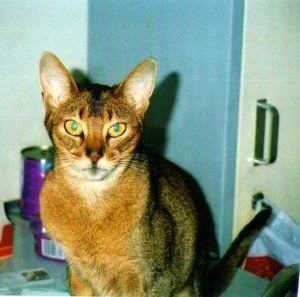

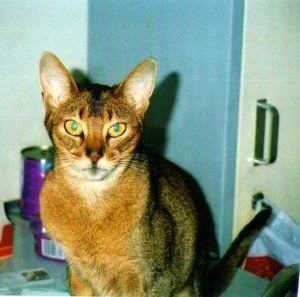

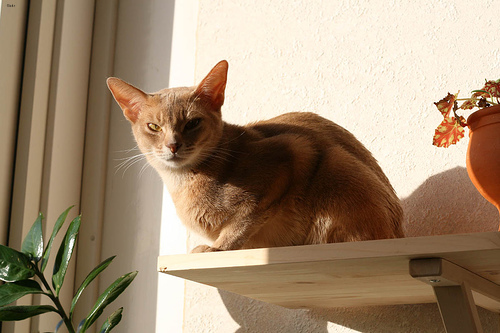

In [15]:
out_dir = Path(CONFIG["output_dir"]) / "blob_reader_resolved"
out_dir.mkdir(parents=True, exist_ok=True)

rows_resolved = spark.sql(f"""
    SELECT image_id, category, read_blob(image_bytes) AS data
    FROM {RESOLVE_VIEW}
    ORDER BY image_id
    LIMIT {CONFIG['resolved_images_to_save']}
""").collect()

saved_paths = []
for row in rows_resolved:
    bytes_data = bytes(row["data"])
    img = Image.open(io.BytesIO(bytes_data)).convert("RGB")
    out_path = out_dir / f"{row['image_id']}_{row['category'].replace('/', '_')}.png"
    img.save(out_path, format="PNG")
    saved_paths.append(out_path)
    print(f"  ✓ {row['image_id']} ({row['category']}) — {len(bytes_data):,} bytes")

for p in saved_paths:
    display(IPyImage(filename=str(p), width=180))

## 16. Compare footprints — Hudi table vs container

In [16]:
def _dir_size(path: Path) -> int:
    if not path.exists():
        return 0
    return sum(p.stat().st_size for p in path.rglob("*") if p.is_file())

table_size = _dir_size(Path(CONFIG["table_path"]))
print(f"  Hudi table:      {table_size / (1024*1024):7.2f} MB  ({CONFIG['table_path']})")

if CONFIG["blob_mode"] == "out_of_line":
    container_size = Path(CONFIG["blob_container_path"]).stat().st_size
    print(f"  Blob container:  {container_size / (1024*1024):7.2f} MB  ({CONFIG['blob_container_path']})")
    if container_size > 0:
        print(f"  Hudi/container ratio: {table_size / container_size:.3%}  — table holds pointers, not bytes.")
else:
    print("  (INLINE mode: bytes live inside the Hudi base files; no external container.)")

  Hudi table:        82.90 MB  (/tmp/hudi_blob_reader_inline_lance_pets)
  (INLINE mode: bytes live inside the Hudi base files; no external container.)


## 17. Stop Spark (optional)

Skip this cell if you plan to flip the toggles and Run All again — the
existing SparkSession is reused. Run it when you're done with the
notebook to release the JVM.

In [17]:
spark.stop()
print("✓ Spark stopped")

✓ Spark stopped
